In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import jax.numpy as jnp
import numpy as np
import arviz as az
import healpy as hp

sys.path.append("../..")
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from common import *
from utils.validation import *

In [21]:
from likelihoods.npll_jax_2 import log_like_np as log_like_np_2

In [22]:
def ll(data=..., k_max=..., npixROI=...,
       f_ary=..., df_rho_div_f_ary=...,
       zs=..., C=..., Sps_dsk=...):
    # data is unmasked

    # general setting
    nm = mask_plane
    m = mask_plane
    data_in = data[~m]

    # poisson
    mu = jnp.zeros_like(data)[~m]

    # disk: param
    #temp_dsk = disk_template.get_template(zs=zs, C=C)
    temp_dsk = jnp.ones_like(data).astype(jnp.float64)

    # disk: normalization
    A_dsk = 1 / jnp.mean(temp_dsk[~nm])
    temp_dsk = A_dsk * temp_dsk
    npt_compressed = jnp.array([temp_dsk])

    # disk: scd
    theta = []
    vd = truth_dict
    for ips, ps in enumerate(["dsk"]):

        n1 = vd['n1_dsk']
        n2 = vd['n2_dsk']
        n3 = vd['n3_dsk']
        sb1 = vd['sb1_dsk']
        lambda_s = vd['lambdas_dsk']

        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(-1., 2., 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps_dsk / jnp.mean(npt_compressed[ips][~nm] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)

    npt_compressed_in = jnp.array([temp_dsk[~m]])
    
    return log_like_np_2(theta, mu, npt_compressed_in, data_in, f_ary, df_rho_div_f_ary, k_max, npixROI)

## 1. 1D LL

In [ ]:
i_psf = 1

f_ary, df_rho_div_f_ary = pickle.load(open(f"f_infos/gaus_nf100_sigma1e-{i_psf}.p", "rb"))

In [5]:
f_ary, df_rho_div_f_ary = get_psf_info(psf='gaussian', num_f_bins=30, sigma=np.deg2rad(0.1812))

In [5]:
f_ary, df_rho_div_f_ary = get_psf_info(psf='king', num_f_bins=30)

In [13]:
f_ary, df_rho_div_f_ary = get_psf_info(psf='gaussian', num_f_bins=30, sigma=1e-2)

In [17]:
np.sum(f_ary**1*df_rho_div_f_ary)

21.102514173459014

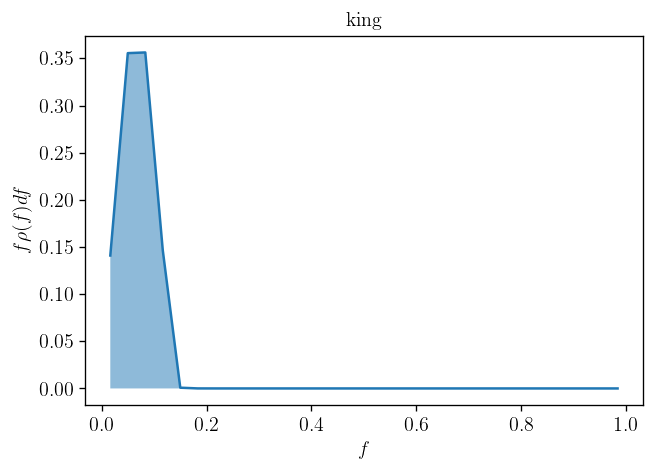

In [14]:
plot_psf(f_ary, df_rho_div_f_ary, 'king');

In [23]:
# calc LL
ll_arr_arr = []
counts_arr = []
base_dir = f'gaus_1e-2'

for i_counts in tqdm(range(100)):
    counts = jnp.array(jnp.load(f"{base_dir}/counts_{i_counts}.npy"), dtype=jnp.int32)
    data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
    data_in[~mask_plane] = counts
    data_in = jnp.asarray(data_in, dtype=jnp.int32)
    k_max = int(np.max(data_in))
    npixROI = int(np.sum(~mask_plane))
    counts_arr.append(np.sum(counts))
    var_dict = truth_dict.copy()

    k = 'Sps_dsk'

    v_arr = np.linspace(1.1, 1.5, 100)
    ll_arr = np.zeros((len(v_arr),))
    for i, v in enumerate(v_arr):
        vd_in = var_dict.copy()
        ll_arr[i] = np.sum(ll(data=data_in, k_max=k_max, npixROI=npixROI,
                              f_ary=f_ary, df_rho_div_f_ary=df_rho_div_f_ary,
                              zs=vd_in['zs'], C=vd_in['C'], Sps_dsk=v))
    ll_arr_arr.append(ll_arr)
counts_arr = np.array(counts_arr)
#pickle.dump(ll_arr_arr, open(f"{base_dir}/ll_Spsdsk_nf100.p", "wb"))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:04<00:00,  1.24s/it]


In [ ]:
# MLE / MAP
S_MLE_arr = []
S_mean_arr = []
for i, ll_arr in enumerate(ll_arr_arr):
    S_MLE, LL_MLE = find_max_point(v_arr, ll_arr)
    S_MLE_arr.append(S_MLE)
    S_mean = np.sum(v_arr * np.exp(ll_arr-LL_MLE)) / np.sum(np.exp(ll_arr-LL_MLE))
    S_mean_arr.append(S_mean)
print(f'MLE = MAP = {np.mean(S_MLE_arr):.4f} +/- {np.std(S_MLE_arr) / np.sqrt(len(S_MLE_arr)):.4f}')
print(f'Post. mean = {np.mean(S_mean_arr):.4f} +/- {np.std(S_mean_arr) / np.sqrt(len(S_mean_arr)):.4f}')

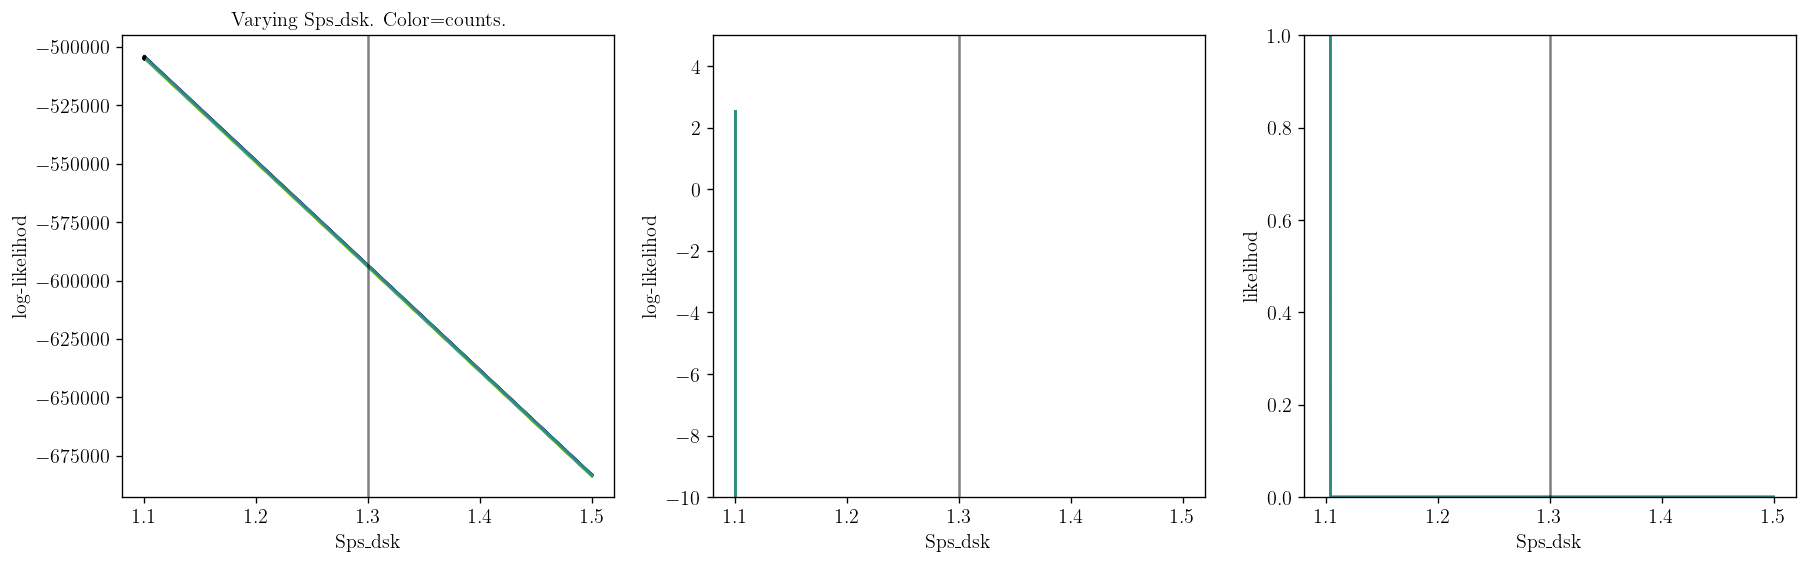

In [24]:
plot_1dll(ll_arr_arr, v_arr, truth_dict['Sps_dsk'], counts_s=counts_arr, xlabel='Sps_dsk');

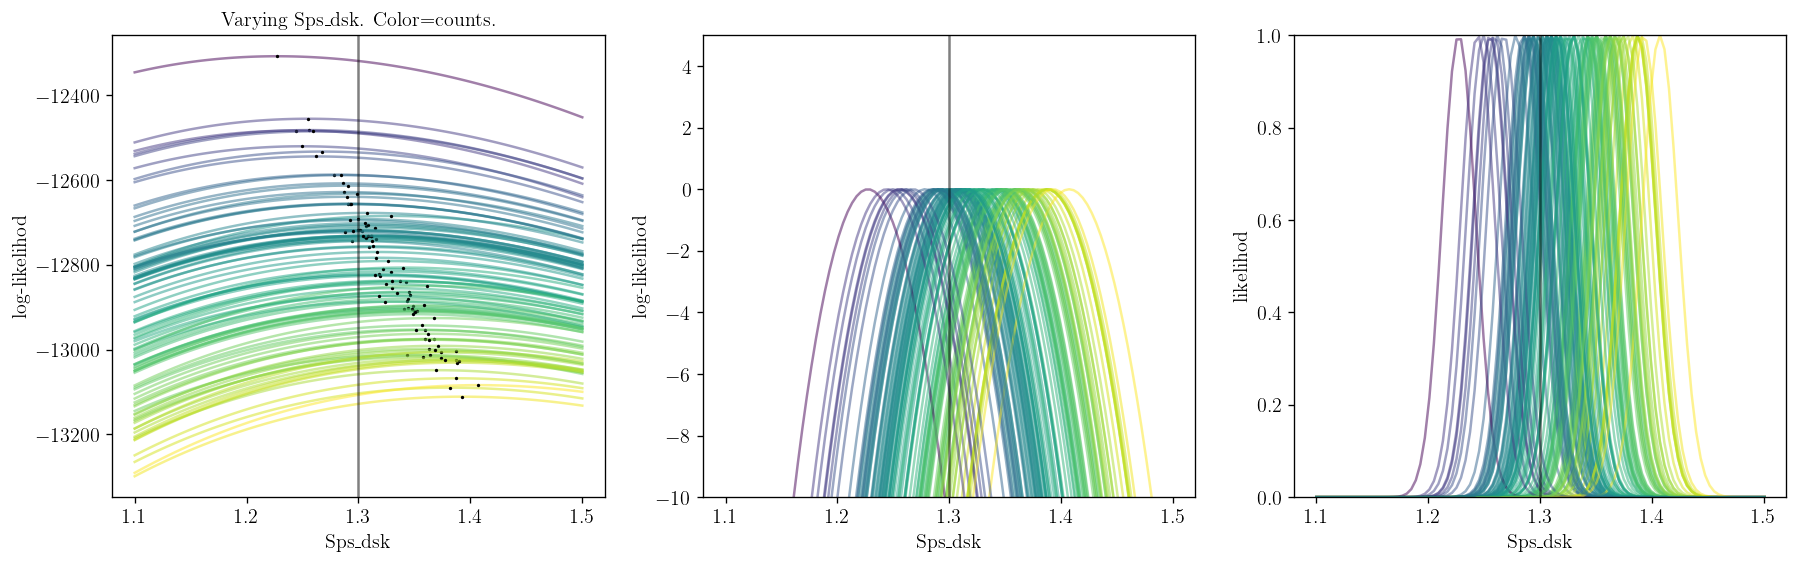

In [ ]:
plot_1dll(ll_arr_arr, v_arr, truth_dict['Sps_dsk'], counts_s=counts_arr, xlabel='Sps_dsk');

### 1.1 coverage

In [21]:
#ll_ss = pickle.load(open(f"{base_dir}/ll_Spsdsk_nf100.p", "rb"))
v_s = np.linspace(1.1, 1.5, 100)
prob_samples = [find_pdf_hdi_prob(np.exp(ll_s-np.max(ll_s)), v_s, truth_dict['Sps_dsk']) for ll_s in ll_ss]

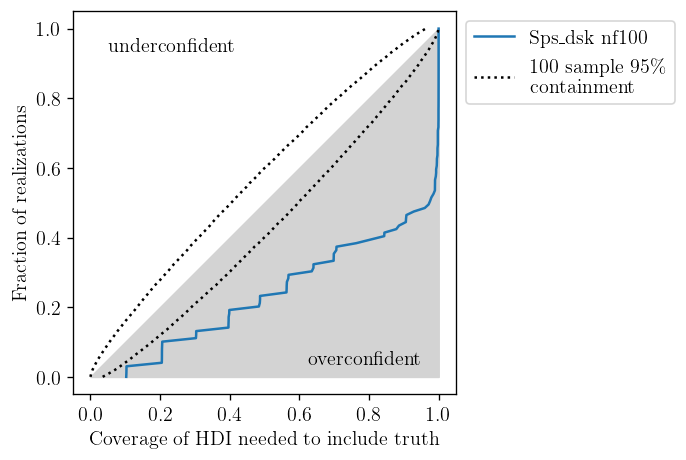

In [22]:
plot_coverage([prob_samples], ['Sps_dsk nf100']);

## 2. 2D LL

In [4]:
def find_contour_levels(hist, levels=[0.95, 0.68]):
    """
    Find the histogram count levels corresponding to the specified containment percentages.
    
    Parameters:
    - hist: 2D array of histogram counts.
    - levels: List of containment levels (e.g., [0.68, 0.95] for 68% and 95% containment).
    
    Returns:
    - A dictionary with the containment levels as keys and the corresponding count levels as values.
    """
    # Flatten the histogram to work with the counts directly
    hist_flat = hist.flatten()
    
    # Sort the counts in descending order
    hist_sorted = np.sort(hist_flat)[::-1]
    
    # Compute the cumulative distribution
    cum_dist = np.cumsum(hist_sorted)
    
    # Normalize the cumulative distribution to go from 0 to 1
    cum_dist_normalized = cum_dist / cum_dist[-1]
    
    # Find the count levels corresponding to the specified containment percentages
    contour_levels = []
    for level in levels:
        # Find the index where cum_dist_normalized exceeds the desired level
        idx = np.where(cum_dist_normalized > level)[0][0]
        # The corresponding count level is the value in hist_sorted at this index
        contour_levels.append(hist_sorted[idx])
    
    return contour_levels

### 2.1 calc LL

In [5]:
def get_ll_ss(ind, use_tqdm=True):

    counts = np.load(f"deltapsf/counts_{ind}.npy")
    data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
    data_in[~mask_plane] = counts
    data_in = jnp.asarray(data_in, dtype=jnp.int32)
    k_max = int(np.max(data_in))
    npixROI = int(np.sum(~mask_plane))

    Sps_arr = np.linspace(1.2, 1.5, 30)
    zs_arr = np.linspace(0.4, 0.8, 30)

    ll_ss = []
    S_range = Sps_arr if not use_tqdm else tqdm(Sps_arr)
    for Sps in S_range:
        ll_s = []
        for zs in zs_arr:
            ll_s.append(ll(data=data_in, k_max=k_max, npixROI=npixROI, deltapsf=True,
                           zs=zs, C=2.5, Sps_dsk=Sps))
        ll_ss.append(ll_s)
    ll_ss = np.sum(ll_ss, axis=-1)

    return Sps_arr, zs_arr, ll_ss

In [16]:
ll_info_s = []
for ind in tqdm(range(100)):
    ll_info_s.append(get_ll_ss(ind, use_tqdm=False))
pickle.dump(ll_info_s, open("deltapsf/ll_info_s.p", "wb"))

100%|██████████| 100/100 [21:50<00:00, 13.10s/it]


### 2.2 plot

In [15]:
for ind in range(10):

    # samples = pickle.load(open(f"deltapsf/hmc_samples_{ind}.p", "rb"))
    # xs = samples['Sps_dsk']
    # ys = samples['zs']
    # hist, xe, ye = np.histogram2d(xs, ys, bins=30, range=[[1.2, 1.5], [0.4, 0.8]])
    # x = (xe[1:] + xe[:-1])/2
    # y = (ye[1:] + ye[:-1])/2
    # levels = find_contour_levels(hist, levels=[0.95, 0.68])

    xl, yl, ll_ss = ll_info_s[ind]
    xtrue = truth_dict['Sps_dsk']
    ytrue = truth_dict['zs']

    plot_labels = dict(xlabel="Sps", ylabel="zs")

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # ax = axs[0]
    # ax.contour(x, y, hist.T, cmap='cool', levels=levels)
    # ax.plot(xtrue, ytrue, '*', color='k', ms=10)
    # ax.set(title=f'ind={ind} HMC post.', **plot_labels)

    ax = axs[1]
    post = np.exp(ll_ss-np.max(ll_ss))
    levels = find_contour_levels(post, levels=[0.95, 0.68])
    ct = ax.contour(xl, yl, post.T, cmap='cool', levels=levels)
    ax.clabel(ct, inline=True, fontsize=10)
    ax.plot(xtrue, ytrue, '*', color='k', ms=10)
    ax.set(title=f'ind={ind} LL-max(LL)', **plot_labels)

    plt.savefig(f"tmp/{ind}.png");
    plt.close();

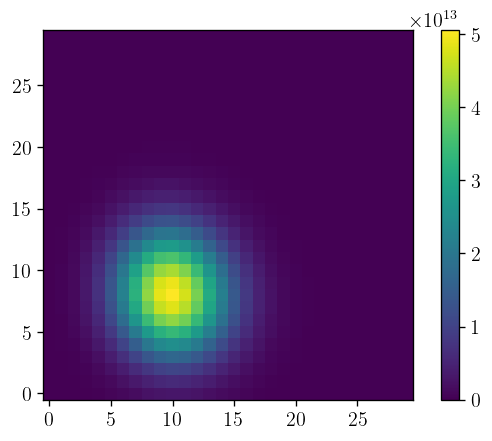

In [14]:
plt.imshow(post, origin='lower')
plt.colorbar();

## 3. 1D LL marginal coverage

100%|██████████| 100/100 [00:00<00:00, 2585.87it/s]


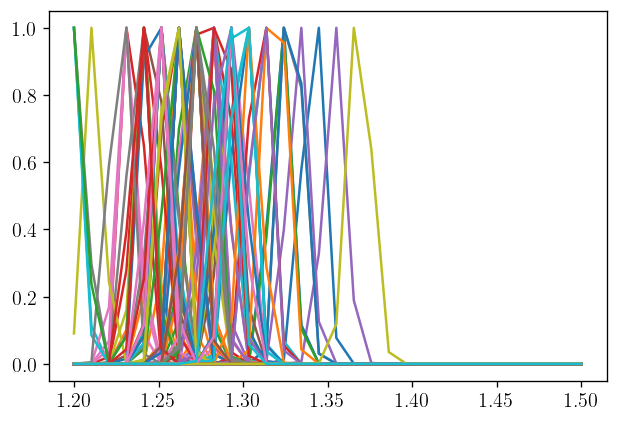

In [18]:
ll_ss_samples = pickle.load(open("deltapsf/ll_info_s.p", "rb"))
prob_samples = []

for ind in tqdm(range(100)):
    xl, yl, ll_ss = ll_ss_samples[ind]
    ll_marginal = np.sum(ll_ss, axis=0)
    post = np.exp(ll_marginal-np.max(ll_marginal))
    plt.plot(xl, post / np.max(post))

In [ ]:
ll_ss_samples = pickle.load(open("deltapsf/ll_info_s.p", "rb"))
prob_samples = []

for ind in tqdm(range(100)):
    xl, yl, ll_ss = ll_ss_samples[ind]
    ll_marginal = np.sum(ll_ss, axis=0)
    post = np.exp(ll_marginal-np.max(ll_marginal))
    prob_samples.append(find_pdf_hdi_prob(post, xl, truth_dict['Sps_dsk']))

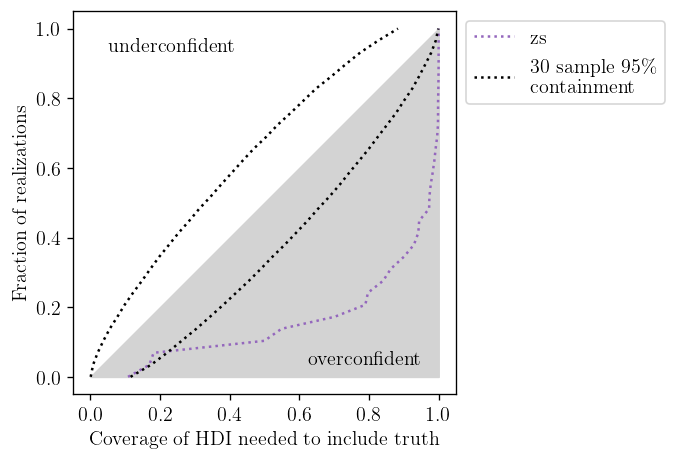

In [ ]:
n_run = 30
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
ax.plot(np.sort(prob_samples), np.linspace(0, 1, n_run), label=k, color=f'C0', linestyle='-')

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout();

## 3. 2D LL coverage

In [33]:
def find_2d_hdi_prob(pdf_ss, x_edges, y_edges, x_truth, y_truth):
    i_x = np.searchsorted(x_edges, x_truth)
    i_y = np.searchsorted(y_edges, y_truth)
    pdf_truth = pdf_ss[i_x, i_y]
    pdf_flat = pdf_ss.flatten()
    return np.sum(pdf_flat[pdf_flat >= pdf_truth]) / np.sum(pdf_flat)

def centers_to_edges(centers):
    edges = (centers[1:] + centers[:-1]) / 2
    edges = np.insert(edges, 0, centers[0] - (edges[0] - centers[0]))
    edges = np.append(edges, centers[-1] + (centers[-1] - edges[-1]))
    return edges

In [34]:
ll_ss_samples = pickle.load(open("deltapsf/ll_info_s.p", "rb"))
prob_samples = []

for ind in range(100):

    ll_ss = ll_ss_samples[ind]
    xe = centers_to_edges(xl)
    ye = centers_to_edges(yl)
    x_truth = truth_dict['Sps_dsk']
    y_truth = truth_dict['zs']
    post = np.exp(ll_ss-np.mean(ll_ss))
    prob = find_2d_hdi_prob(post, xe, ye, x_truth, y_truth)
    prob_samples.append(prob)

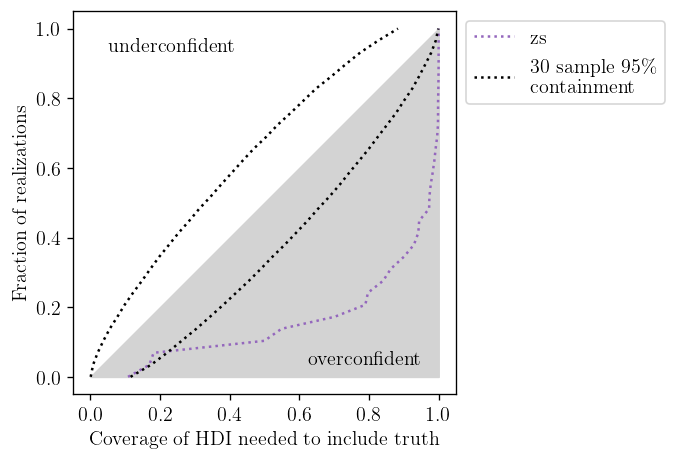

In [31]:
n_run = 30
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

view_keys = list(samples.keys())

linestyles = ['-', '--', ':', '-.']

ax.fill_between([0,1], [0,1], color='lightgray')



ax.plot(np.sort(prob_samples), np.linspace(0, 1, n_run), label=k, color=f'C{i%10}', linestyle=linestyles[i//10])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout();

## A. total counts

In [20]:
S_arr = []
for i in range(300):
    counts = np.load(f"base/counts_{i}.npy")
    S_arr.append(np.sum(counts) / np.sum(~mask_plane))

1.300760572439299 0.002229255416727171


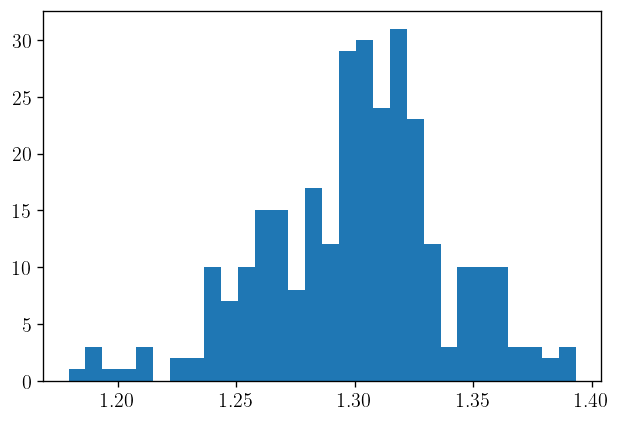

In [21]:
plt.hist(S_arr, bins=30)
print(np.mean(S_arr), np.std(S_arr) / np.sqrt(len(S_arr)))

## B. generate f info

In [5]:
for i in tqdm([0, 1, 2, 3, 4, 5]):
    f_ary, df_rho_div_f_ary = get_psf_info(psf='gaussian', num_f_bins=100, sigma=10**(-i))
    pickle.dump((f_ary, df_rho_div_f_ary), open(f"f_infos/gaus_nf100_sigma1e-{i}.p", "wb"))

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [01:30<00:00, 15.06s/it]
